In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

In [111]:
df = pd.read_csv('HR_comma_sep.csv')

In [112]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [113]:
empty_strings = (df == '').sum()
print("\nEmpty strings per column:")
print(empty_strings)


Empty strings per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [114]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns


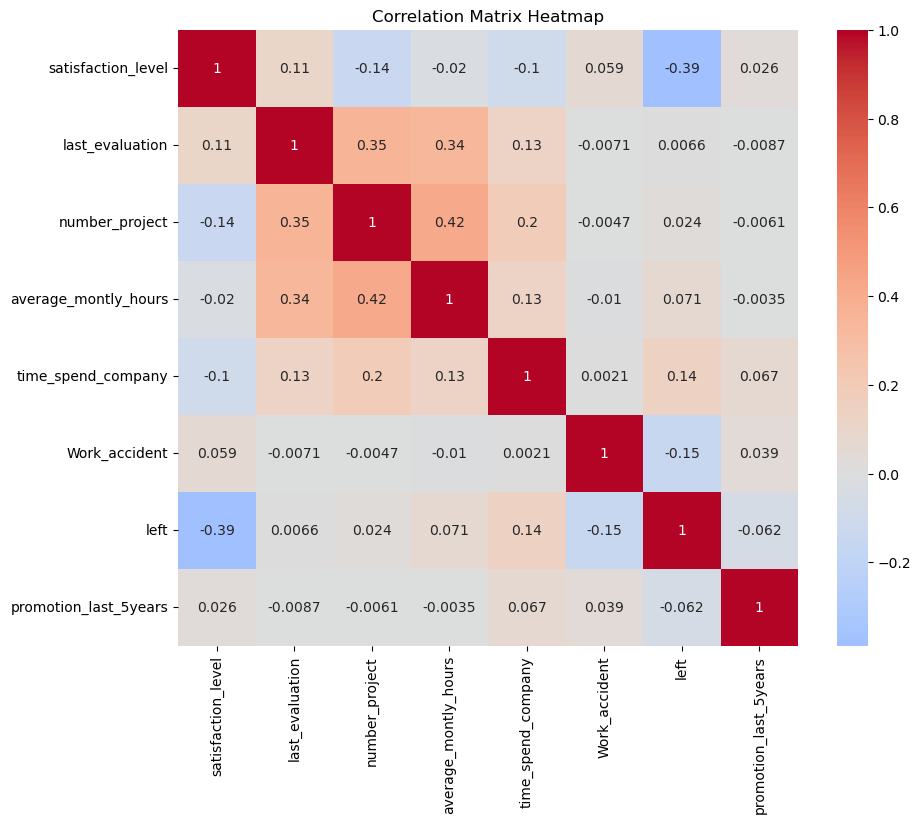

In [115]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()


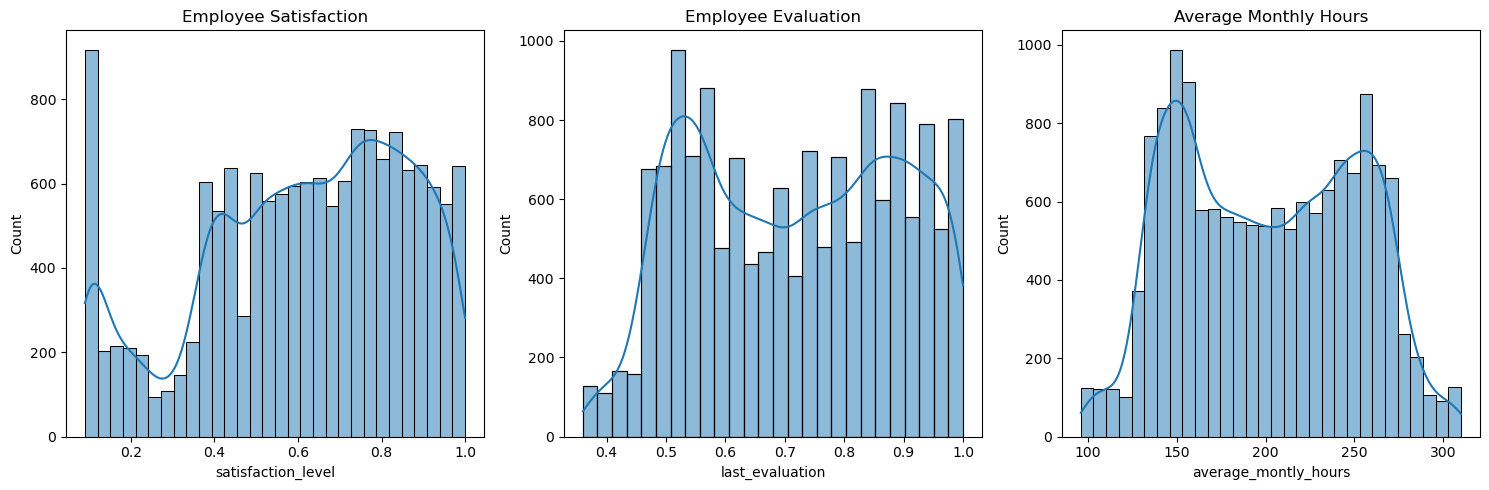

In [116]:
plt.figure(figsize=(15,5))

# Employee Satisfaction
plt.subplot(1,3,1)
sns.histplot(data=df, x='satisfaction_level', kde=True)
plt.title('Employee Satisfaction')

# Employee Evaluation
plt.subplot(1,3,2)
sns.histplot(data=df, x='last_evaluation', kde=True)
plt.title('Employee Evaluation')

# Employee Average Monthly Hours
plt.subplot(1,3,3)
sns.histplot(data=df, x='average_montly_hours', kde=True)
plt.title('Average Monthly Hours')

plt.tight_layout()
plt.show()


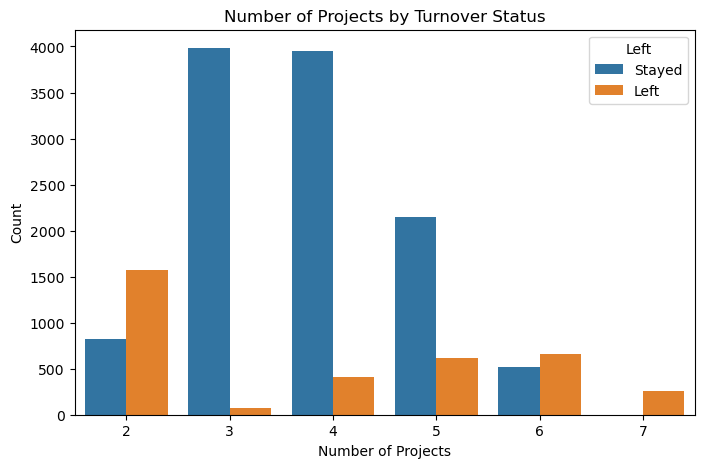

In [117]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Number of Projects by Turnover Status')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.show()

In [118]:
left_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

C:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(


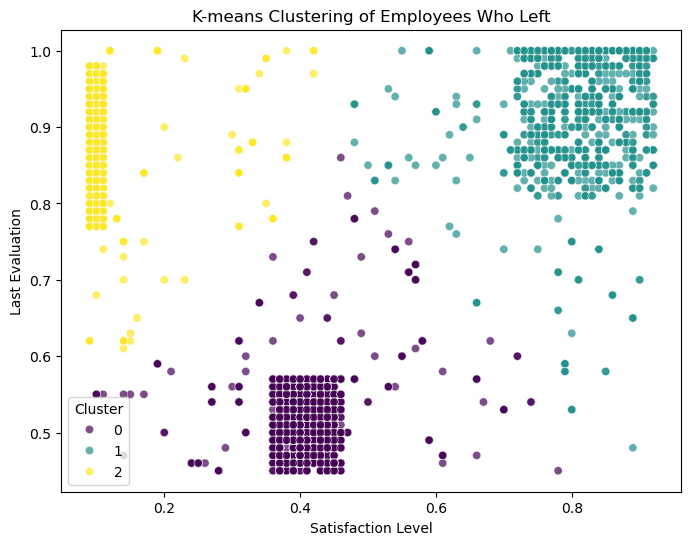

In [119]:
left_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
left_df['cluster'] = kmeans.fit_predict(left_df)

# Plot the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=left_df, x='satisfaction_level', y='last_evaluation', hue='cluster', palette='viridis', alpha=0.7)
plt.title('K-means Clustering of Employees Who Left')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.show()

In [120]:
categorical_cols = ['sales', 'salary']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['left']]

In [121]:
df_dummies = pd.get_dummies(df[categorical_cols], drop_first=True)

In [122]:
X = pd.concat([df[numerical_cols], df_dummies], axis=1)
y = df['left']

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

In [124]:
print("Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
left
0    9142
1    2857
Name: count, dtype: int64

After SMOTE:
left
0    9142
1    9142
Name: count, dtype: int64


In [125]:
# Standardize numerical features (excluding dummies)
scaler = StandardScaler()
num_cols = numerical_cols.copy()


In [126]:
X_train_smote[num_cols] = scaler.fit_transform(X_train_smote[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [127]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [128]:
lr = LogisticRegression(max_iter=1000, random_state=42)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_scores = cross_val_score(lr, X_train_smote, y_train_smote, cv=kfold, scoring='f1')
print("Logistic Regression F1 scores (5-fold CV):", lr_scores)
print("Mean F1:", np.mean(lr_scores))


Logistic Regression F1 scores (5-fold CV): [0.79234973 0.81015973 0.79431483 0.80277186 0.79765708]
Mean F1: 0.7994506442358419


In [129]:
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.66      0.76      2286
           1       0.41      0.76      0.54       714

    accuracy                           0.69      3000
   macro avg       0.66      0.71      0.65      3000
weighted avg       0.78      0.69      0.71      3000



In [130]:
rf = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf, X_train_smote, y_train_smote, cv=kfold, scoring='f1')
print("\nRandom Forest F1 scores (5-fold CV):", rf_scores)
print("Mean F1:", np.mean(rf_scores))


Random Forest F1 scores (5-fold CV): [0.9845047  0.98259188 0.98507463 0.98369715 0.98480243]
Mean F1: 0.9841341585049189


In [131]:
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      2286
           1       0.00      0.00      0.00       714

    accuracy                           0.76      3000
   macro avg       0.38      0.50      0.43      3000
weighted avg       0.58      0.76      0.66      3000



C:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [132]:
gb = GradientBoostingClassifier(random_state=42)
gb_scores = cross_val_score(gb, X_train_smote, y_train_smote, cv=kfold, scoring='f1')
print("\nGradient Boosting F1 scores (5-fold CV):", gb_scores)
print("Mean F1:", np.mean(gb_scores))

gb.fit(X_train_smote, y_train_smote)
y_pred_gb = gb.predict(X_test)
print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting F1 scores (5-fold CV): [0.96288089 0.95997792 0.96213808 0.96228508 0.96277778]
Mean F1: 0.9620119496220376

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      2286
           1       0.50      0.00      0.00       714

    accuracy                           0.76      3000
   macro avg       0.63      0.50      0.43      3000
weighted avg       0.70      0.76      0.66      3000



In [133]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}


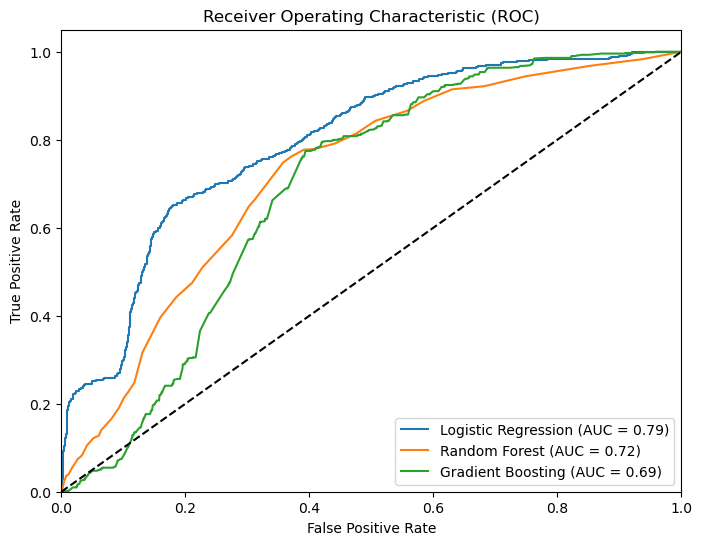

In [134]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    # Get predicted probabilities for the positive class
    y_proba = model.predict_proba(X_test)[:, 1]
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
    disp.plot()
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

    # Print confusion matrix as table for clarity
    print(f"\n{name} Confusion Matrix:")
    print(cm)

In [ ]:
print("""
**Which metric to use from the confusion matrix: Recall or Precision?**

- **Recall (Sensitivity/True Positive Rate):**
  - Measures the proportion of actual positives (employees who left) correctly identified by the model.
  - High recall means the model finds most employees who will leave, minimizing false negatives.
  - **Use case:** If the cost of missing an employee who will leave (false negative) is high, prioritize recall.

- **Precision:**
  - Measures the proportion of predicted positives (predicted to leave) that are actually positive.
  - High precision means when the model predicts an employee will leave, it is usually correct.
  - **Use case:** If falsely predicting someone will leave (false positive) is costly, prioritize precision.

**For employee turnover prediction, usually recall is more important because missing employees who will leave (false negatives) is costlier than false alarms (false positives).**
""")


In [ ]:
categorical_cols = ['sales', 'salary']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['left']]
df_dummies = pd.get_dummies(df[categorical_cols], drop_first=True)
X = pd.concat([df[numerical_cols], df_dummies], axis=1)
y = df['left']


In [141]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)


In [142]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1] 

NameError: name 'best_model' is not defined

In [143]:
def categorize_risk(prob):
    if prob < 0.2:
        return 'Safe Zone (Green)'
    elif prob < 0.6:
        return 'Low-Risk Zone (Yellow)'
    elif prob < 0.9:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

risk_zones = [categorize_risk(p) for p in y_pred_proba]
X_test['turnover_probability'] = y_pred_proba
X_test['risk_zone'] = risk_zones

# Count employees in each zone
zone_counts = X_test['risk_zone'].value_counts()
print("Number of employees in each risk zone:")
print(zone_counts)

# Retention strategies for each zone
print("\nSuggested Retention Strategies for Each Zone:")

print("\nSafe Zone (Green) (Score < 20%):")
print("- Maintain current engagement and satisfaction levels.")
print("- Regular check-ins to ensure continued satisfaction.")
print("- Continue to provide growth opportunities.")

print("\nLow-Risk Zone (Yellow) (20% < Score < 60%):")
print("- Identify and address specific concerns (e.g., workload, recognition).")
print("- Offer targeted professional development or mentorship.")
print("- Increase communication and feedback frequency.")

print("\nMedium-Risk Zone (Orange) (60% < Score < 90%):")
print("- Immediate intervention by HR or management.")
print("- Conduct stay interviews to understand concerns.")
print("- Offer customized retention plans (e.g., flexible hours, promotions).")
print("- Consider salary or benefits review if appropriate.")

print("\nHigh-Risk Zone (Red) (Score > 90%):")
print("- Highest priority for retention efforts.")
print("- Direct manager or executive outreach.")
print("- Personalized retention packages (bonuses, career pathing).")
print("- If retention fails, conduct exit interviews to gather insights.")

NameError: name 'y_pred_proba' is not defined